In [1]:
from pathlib import Path
import yaml
import numpy as np
from torch.utils.data import DataLoader
import wandb

from torchvision.models import resnet18
import pytorch_lightning as pl
from pytorch_lightning.loggers import WandbLogger
from torch.nn import CrossEntropyLoss
from torch.utils.data import random_split, DataLoader
from pytorch_lightning.callbacks import ModelCheckpoint

from sklearn.metrics import roc_curve, auc, precision_score, recall_score
import matplotlib.pyplot as plt
from omegaconf import OmegaConf
from hydra.utils import instantiate

import os
import torch
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))
from datasets import get_celeba_dataset

In [2]:
filename = Path("/home/erogullari/Workspace/cav-disentanglement/configs/dataset/celeba.yaml")
device = "cuda"

with open(filename, "r") as fp:
    config = OmegaConf.load(fp)

In [3]:
dataset = instantiate(config)
print(dataset.classes)
len(dataset)

['Non-Blond_Hair', 'Blond_Hair']


202599

In [4]:
concept_names = dataset.get_concept_names()
for i, name in enumerate(concept_names):
    print(f"Concept {i}: {name}")

Concept 0: 5_o_Clock_Shadow
Concept 1: Arched_Eyebrows
Concept 2: Attractive
Concept 3: Bags_Under_Eyes
Concept 4: Bald
Concept 5: Bangs
Concept 6: Big_Lips
Concept 7: Big_Nose
Concept 8: Black_Hair
Concept 9: Blond_Hair
Concept 10: Blurry
Concept 11: Brown_Hair
Concept 12: Bushy_Eyebrows
Concept 13: Chubby
Concept 14: Double_Chin
Concept 15: Eyeglasses
Concept 16: Goatee
Concept 17: Gray_Hair
Concept 18: Heavy_Makeup
Concept 19: High_Cheekbones
Concept 20: Male
Concept 21: Mouth_Slightly_Open
Concept 22: Mustache
Concept 23: Narrow_Eyes
Concept 24: No_Beard
Concept 25: Oval_Face
Concept 26: Pale_Skin
Concept 27: Pointy_Nose
Concept 28: Receding_Hairline
Concept 29: Rosy_Cheeks
Concept 30: Sideburns
Concept 31: Smiling
Concept 32: Straight_Hair
Concept 33: Wavy_Hair
Concept 34: Wearing_Earrings
Concept 35: Wearing_Hat
Concept 36: Wearing_Lipstick
Concept 37: Wearing_Necklace
Concept 38: Wearing_Necktie
Concept 39: Young


In [5]:
from models import get_lenet5, get_resnet18, get_simplenet, get_vgg16

in_channels = 3
input_size = config.image_size
model_name = "vgg16"
# model = get_lenet5(n_class=dataset.num_classes, in_channels=in_channels, input_size=input_size).to(device)
# model = get_simplenet(n_class=dataset.num_classes, in_channels=in_channels, input_size=input_size).to(device)
# model = get_resnet18(n_class=dataset.num_classes, pretrained=False).to(device)
model = get_vgg16(n_class=dataset.num_classes, pretrained=False).to(device)

/home/erogullari/miniconda3/envs/xai/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
# Sanity check
loader = DataLoader(dataset, batch_size=8, shuffle=True, num_workers=4)
x, y = next(iter(loader))
print("x shape: ", x.shape)
print("y shape: ", y.shape)

y = y.long().view(-1)
y_mc = torch.nn.functional.one_hot(y, num_classes=2).float()
print("y: ", y)
print("y_mc: ", y_mc)

logits = model(x.to(device))
print("logits: ", logits)
preds = torch.argmax(logits, dim=1).cpu()
print("preds: ", preds)

x shape:  torch.Size([8, 3, 224, 224])
y shape:  torch.Size([8])
y:  tensor([0, 0, 0, 0, 1, 0, 0, 0])
y_mc:  tensor([[1., 0.],
        [1., 0.],
        [1., 0.],
        [1., 0.],
        [0., 1.],
        [1., 0.],
        [1., 0.],
        [1., 0.]])
logits:  tensor([[-0.0082,  0.0383],
        [ 0.0397,  0.0076],
        [-0.0220,  0.0506],
        [-0.0250, -0.0149],
        [-0.0271,  0.0222],
        [-0.0046,  0.0284],
        [ 0.0264,  0.0484],
        [ 0.0074, -0.0095]], device='cuda:0', grad_fn=<AddmmBackward0>)
preds:  tensor([1, 0, 1, 1, 1, 1, 1, 0])


In [7]:
from torchmetrics import Precision, Recall, F1Score, Accuracy
from torch.nn.functional import one_hot

class Classifier(pl.LightningModule):
    def __init__(self, model, num_classes, learning_rate=1e-3):
        super().__init__()
        self.model = model
        self.learning_rate = learning_rate
        self.num_classes = num_classes
        self.loss = CrossEntropyLoss()
        
        self.accuracy = Accuracy(task="multiclass", num_classes=num_classes)
        self.precision = Precision(task="multiclass", num_classes=num_classes, average="macro")
        self.recall = Recall(task="multiclass", num_classes=num_classes, average="macro")
        self.f1 = F1Score(task="multiclass", num_classes=num_classes, average="macro")
        
    def forward(self, x):
        return self.model(x)
    
    def training_step(self, batch, batch_idx):
        x, y = batch
        y = y.long().view(-1)
        y_mc = one_hot(y, num_classes=2).float()
        logits = self(x)
        loss = self.loss(logits, y_mc)
        preds = torch.argmax(logits, dim=1)
        self.log("train_loss", loss)
        self.log("train_precision", self.precision(preds, y))
        self.log("train_recall", self.recall(preds, y))
        self.log("train_f1", self.f1(preds, y))
        self.log("train_accuracy", self.accuracy(preds, y))
        return loss
    
    def validation_step(self, batch, batch_idx):
        x, y = batch
        y = y.long().view(-1)
        y_mc = one_hot(y, num_classes=2).float()
        logits = self(x)
        loss = self.loss(logits, y_mc)
        preds = torch.argmax(logits, dim=1)
        
        self.log("val_loss", loss)
        self.log("val_precision", self.precision(preds, y))
        self.log("val_recall", self.recall(preds, y))
        self.log("val_f1", self.f1(preds, y))
        self.log("val_accuracy", self.accuracy(preds, y))
    
    def configure_optimizers(self):
        optimizer = torch.optim.SGD(self.parameters(), lr=self.learning_rate)
        # scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
        return {
            "optimizer": optimizer,
            # "lr_scheduler": {
            #     "scheduler": scheduler,
            #     "interval": "epoch",  # or "step"
            #     "frequency": 1,
            # },
        }


## Optional Legacy VGG Classifier Training

This section preserves the supervised VGG baseline. It is not needed for the default CLIP evaluation below. Keep `RUN_VGG_TRAINING = False` unless you explicitly want to retrain the legacy classifier.

In [8]:
RUN_VGG_TRAINING = False
wandb_logger = None
if RUN_VGG_TRAINING:
    WANDB_API_KEY = os.getenv("WANDB_API_KEY")
    wandb.login(key=WANDB_API_KEY)
    wandb_project_name = "vgg16-celeba"
    wandb_logger = WandbLogger(
        project=wandb_project_name,
        name=f"classifier:{model_name}-blonde_hair-bce",
    )

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /home/erogullari/.netrc


wandb: Currently logged in as: erogullari (hhixai) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [9]:
# Create checkpoint callback
checkpoint_callback = ModelCheckpoint(
    dirpath="/media/erogullari/checkpoints/cache/",
    filename=f"{model_name}" + "-blonde_hair-bce-{epoch:02d}-{val_loss:.2f}",
    monitor="val_loss",
    mode="min",
    save_top_k=3,
    verbose=True
)

lightning_model = Classifier(model, dataset.num_classes)
trainer = pl.Trainer(
    max_epochs=20,
    accelerator="gpu",
    devices=1,
    logger=wandb_logger,
    callbacks=[checkpoint_callback]
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [10]:
# Split dataset
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

print(f"Train size: {len(train_dataset)}, Val size: {len(val_dataset)}")
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

Train size: 162079, Val size: 40520


In [11]:
if RUN_VGG_TRAINING:
    trainer.fit(lightning_model, train_loader, val_loader)

/home/erogullari/miniconda3/envs/xai/lib/python3.10/site-packages/torch/__init__.py:1551: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  return _C._get_float32_matmul_precision()
You are using a CUDA device ('NVIDIA GeForce RTX 3060') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#t

/home/erogullari/miniconda3/envs/xai/lib/python3.10/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:751: Checkpoint directory /media/erogullari/checkpoints/cache exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type                | Params | Mode 
----------------------------------------------------------
0 | model     | VGG                 | 134 M  | train
1 | loss      | CrossEntropyLoss    | 0      | train
2 | accuracy  | MulticlassAccuracy  | 0      | train
3 | precision | MulticlassPrecision | 0      | train
4 | recall    | MulticlassRecall    | 0      | train
5 | f1        | MulticlassF1Score   | 0      | train
----------------------------------------------------------
134 M     Trainable params
0         Non-trainable params
134 M     Total params
537.075   Total estimated model params size (MB)
48        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/erogullari/miniconda3/envs/xai/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:433: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.


/home/erogullari/miniconda3/envs/xai/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.


...


Detected KeyboardInterrupt, attempting graceful shutdown ...


SystemExit: 1

/home/erogullari/miniconda3/envs/xai/lib/python3.10/site-packages/IPython/core/interactiveshell.py:3587: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)
socket.send() raised exception.
socket.send() raised exception.
socket.send() raised exception.
socket.send() raised exception.
socket.send() raised exception.
socket.send() raised exception.
socket.send() raised exception.


Error in callback <bound method _WandbInit._post_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x711ce91c7010>> (for post_run_cell), with arguments args (<ExecutionResult object at 711cde2df280, execution_count=11 error_before_exec=None error_in_exec=1 info=<ExecutionInfo object at 711cde2dd1e0, raw_cell="trainer.fit(lightning_model, train_loader, val_loa.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell://ssh-remote%2Bworkstation/home/erogullari/Workspace/cav-disentanglement/notebooks/train_gender_necktie_classifier.ipynb#X14sdnNjb2RlLXJlbW90ZQ%3D%3D> result=None>,),kwargs {}:


BrokenPipeError: [Errno 32] Broken pipe

In [12]:
# Get predictions on validation set
lightning_model.eval().to(device)
all_preds = []
all_labels = []

with torch.no_grad():
    for x, y in val_loader:
        x = x.to(device)
        logits = lightning_model(x)
        preds = torch.sigmoid(logits).cpu().numpy()
        all_preds.append(preds)
        all_labels.append(y.numpy())

all_preds = np.concatenate(all_preds, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

In [13]:
accuracy = ((all_preds > .5) * 1 == all_labels).mean()  # type: ignore
print(f"Validation Accuracy: {accuracy:.4f}")

ValueError: operands could not be broadcast together with shapes (40520,2) (40520,) 

In [ ]:
from sklearn.metrics import roc_curve, auc, precision_score, recall_score, confusion_matrix

num_classes = all_preds.shape[1]

# per-class ROC + precision/recall at 0.5
fpr = {}
tpr = {}
roc_auc = {}
precision_per = {}
recall_per = {}
support_per = {}

for i in range(num_classes):
    y_true = all_labels[:, i].astype(int)
    y_score = all_preds[:, i]
    y_pred = (y_score > 0.5).astype(int)

    # precision / recall at threshold 0.5 (sklearn)
    precision_per[i] = precision_score(y_true, y_pred, zero_division=0)
    recall_per[i] = recall_score(y_true, y_pred, zero_division=0)

    # support and confusion for diagnostics
    support_per[i] = int(y_true.sum())
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    print(f"cls {i}: support={support_per[i]}  TP={tp}  FP={fp}  FN={fn}  TN={tn}  precision={precision_per[i]:.3f}  recall={recall_per[i]:.3f}")

# macro averages (use sklearn to match torchmetrics)
precision_macro = precision_score(all_labels.astype(int), (all_preds > 0.5).astype(int), average="macro", zero_division=0)
recall_macro = recall_score(all_labels.astype(int), (all_preds > 0.5).astype(int), average="macro", zero_division=0)


print("\nSummary:")
print(f"Macro Precision@0.5: {precision_macro:.3f}")
print(f"Macro Recall@0.5:    {recall_macro:.3f}")

cls 0: support=19  TP=15  FP=0  FN=4  TN=1981  precision=1.000  recall=0.789
cls 1: support=21  TP=12  FP=0  FN=9  TN=1979  precision=1.000  recall=0.571
cls 2: support=19  TP=15  FP=0  FN=4  TN=1981  precision=1.000  recall=0.789
cls 3: support=169  TP=144  FP=11  FN=25  TN=1820  precision=0.929  recall=0.852
cls 4: support=19  TP=16  FP=3  FN=3  TN=1978  precision=0.842  recall=0.842
cls 5: support=17  TP=14  FP=6  FN=3  TN=1977  precision=0.700  recall=0.824
cls 6: support=18  TP=17  FP=2  FN=1  TN=1980  precision=0.895  recall=0.944
cls 7: support=192  TP=189  FP=5  FN=3  TN=1803  precision=0.974  recall=0.984
cls 8: support=18  TP=18  FP=5  FN=0  TN=1977  precision=0.783  recall=1.000
cls 9: support=23  TP=22  FP=2  FN=1  TN=1975  precision=0.917  recall=0.957
cls 10: support=16  TP=13  FP=1  FN=3  TN=1983  precision=0.929  recall=0.812
cls 11: support=183  TP=179  FP=2  FN=4  TN=1815  precision=0.989  recall=0.978
cls 12: support=13  TP=7  FP=7  FN=6  TN=1980  precision=0.500  re

cls 103: support=23  TP=6  FP=2  FN=17  TN=1975  precision=0.750  recall=0.261
cls 104: support=225  TP=158  FP=36  FN=67  TN=1739  precision=0.814  recall=0.702
cls 105: support=128  TP=127  FP=0  FN=1  TN=1872  precision=1.000  recall=0.992
cls 106: support=139  TP=133  FP=0  FN=6  TN=1861  precision=1.000  recall=0.957
cls 107: support=126  TP=120  FP=0  FN=6  TN=1874  precision=1.000  recall=0.952
cls 108: support=17  TP=17  FP=5  FN=0  TN=1978  precision=0.773  recall=1.000
cls 109: support=20  TP=12  FP=1  FN=8  TN=1979  precision=0.923  recall=0.600
cls 110: support=31  TP=22  FP=3  FN=9  TN=1966  precision=0.880  recall=0.710
cls 111: support=229  TP=203  FP=16  FN=26  TN=1755  precision=0.927  recall=0.886
cls 112: support=26  TP=23  FP=5  FN=3  TN=1969  precision=0.821  recall=0.885
cls 113: support=18  TP=15  FP=3  FN=3  TN=1979  precision=0.833  recall=0.833
cls 114: support=30  TP=27  FP=1  FN=3  TN=1969  precision=0.964  recall=0.900
cls 115: support=215  TP=211  FP=15  F

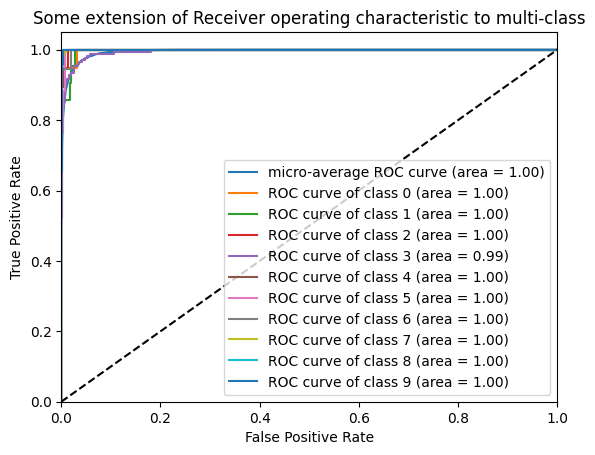

In [ ]:
num_classes_roc = 10

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(num_classes_roc):

    fpr[i], tpr[i], _ = roc_curve(all_labels[:, i], all_preds[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(all_labels.ravel(), all_preds.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])


# Plot ROC curve
plt.figure()
plt.plot(fpr["micro"], tpr["micro"],
         label='micro-average ROC curve (area = {0:0.2f})'
               ''.format(roc_auc["micro"]))
for i in range(num_classes_roc):
    plt.plot(fpr[i], tpr[i], label='ROC curve of class {0} (area = {1:0.2f})'
                                   ''.format(i, roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Some extension of Receiver operating characteristic to multi-class')
plt.legend(loc="lower right")
plt.show()

In [ ]:
ckpt_path = "/media/erogullari/checkpoints/cache/vgg16-eyeglasses-bce-epoch=12-val_loss=0.01.ckpt"
# backbone = get_simplenet(n_class=153, in_channels=3, input_size=224, pretrained=False)
backbone = get_vgg16(n_class=dataset.num_classes, pretrained=False).to(device)
classifier = Classifier.load_from_checkpoint(ckpt_path, model=backbone, num_classes=dataset.num_classes)
classifier.eval().cpu()
save_path = f"/media/erogullari/checkpoints/checkpoint_{model_name}_celeba_eyeglasses.pth"
torch.save(classifier.model.state_dict(), save_path)
print(f"File saved to {save_path}")
list(backbone.named_modules())

File saved to /media/erogullari/checkpoints/checkpoint_vgg16_elements.pth


[('',
  VGG(
    (features): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
      (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (6): ReLU(inplace=True)
      (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (8): ReLU(inplace=True)
      (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (11): ReLU(inplace=True)
      (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (13): ReLU(inplace=True)
      (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (15): ReLU(inplace=True)
      (16): MaxPool2d(ke

In [19]:
# Get predictions on validation set
classifier.eval().to(device)
all_preds = []
all_labels = []

with torch.no_grad():
    for x, y in val_loader:
        x = x.to(device)
        logits = classifier(x)
        preds = torch.sigmoid(logits).cpu().numpy()
        all_preds.append(preds)
        all_labels.append(y.numpy())

all_preds = np.concatenate(all_preds, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

In [20]:
accuracy = ((all_preds > .5) * 1 == all_labels).mean()  # type: ignore
print(f"Validation Accuracy: {accuracy:.4f}")

Validation Accuracy: 0.9740


In [21]:
from sklearn.metrics import roc_curve, auc, precision_score, recall_score, confusion_matrix

num_classes = all_preds.shape[1]

# per-class ROC + precision/recall at 0.5
fpr = {}
tpr = {}
roc_auc = {}
precision_per = {}
recall_per = {}
support_per = {}

for i in range(num_classes):
    y_true = all_labels[:, i].astype(int)
    y_score = all_preds[:, i]
    y_pred = (y_score > 0.5).astype(int)

    # precision / recall at threshold 0.5 (sklearn)
    precision_per[i] = precision_score(y_true, y_pred, zero_division=0)
    recall_per[i] = recall_score(y_true, y_pred, zero_division=0)

    # support and confusion for diagnostics
    support_per[i] = int(y_true.sum())
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    print(f"cls {i}: support={support_per[i]}  TP={tp}  FP={fp}  FN={fn}  TN={tn}  precision={precision_per[i]:.3f}  recall={recall_per[i]:.3f}")

# macro averages (use sklearn to match torchmetrics)
precision_macro = precision_score(all_labels.astype(int), (all_preds > 0.5).astype(int), average="macro", zero_division=0)
recall_macro = recall_score(all_labels.astype(int), (all_preds > 0.5).astype(int), average="macro", zero_division=0)


print("\nSummary:")
print(f"Macro Precision@0.5: {precision_macro:.3f}")
print(f"Macro Recall@0.5:    {recall_macro:.3f}")

cls 0: support=16  TP=4  FP=1  FN=12  TN=1983  precision=0.800  recall=0.250
cls 1: support=22  TP=11  FP=11  FN=11  TN=1967  precision=0.500  recall=0.500
cls 2: support=14  TP=2  FP=2  FN=12  TN=1984  precision=0.500  recall=0.143
cls 3: support=157  TP=31  FP=24  FN=126  TN=1819  precision=0.564  recall=0.197
cls 4: support=13  TP=5  FP=6  FN=8  TN=1981  precision=0.455  recall=0.385
cls 5: support=21  TP=2  FP=5  FN=19  TN=1974  precision=0.286  recall=0.095
cls 6: support=17  TP=4  FP=8  FN=13  TN=1975  precision=0.333  recall=0.235
cls 7: support=180  TP=50  FP=65  FN=130  TN=1755  precision=0.435  recall=0.278
cls 8: support=17  TP=8  FP=2  FN=9  TN=1981  precision=0.800  recall=0.471
cls 9: support=20  TP=15  FP=0  FN=5  TN=1980  precision=1.000  recall=0.750
cls 10: support=15  TP=8  FP=0  FN=7  TN=1985  precision=1.000  recall=0.533
cls 11: support=190  TP=111  FP=1  FN=79  TN=1809  precision=0.991  recall=0.584
cls 12: support=15  TP=5  FP=1  FN=10  TN=1984  precision=0.833 

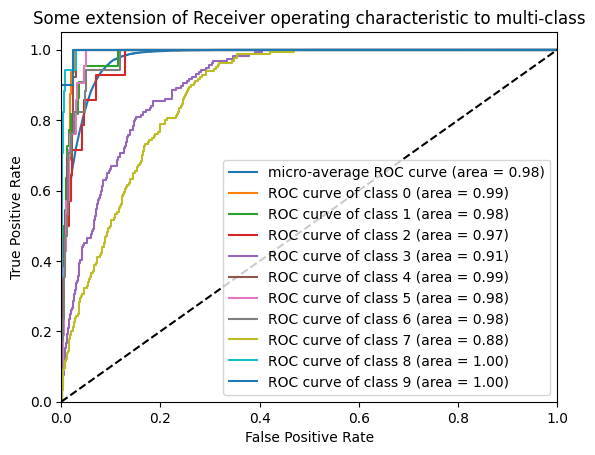

In [22]:
num_classes_roc = 10

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(num_classes_roc):

    fpr[i], tpr[i], _ = roc_curve(all_labels[:, i], all_preds[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(all_labels.ravel(), all_preds.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])


# Plot ROC curve
plt.figure()
plt.plot(fpr["micro"], tpr["micro"],
         label='micro-average ROC curve (area = {0:0.2f})'
               ''.format(roc_auc["micro"]))
for i in range(num_classes_roc):
    plt.plot(fpr[i], tpr[i], label='ROC curve of class {0} (area = {1:0.2f})'
                                   ''.format(i, roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Some extension of Receiver operating characteristic to multi-class')
plt.legend(loc="lower right")
plt.show()

## Activation Steering Evaluation

CLIP is the default backend. Each score is a two-way softmax over fixed negative and positive prompt ensembles, so it is a relative prompt score rather than a calibrated probability. The `gender` score represents the positive CelebA `Male` attribute.

In [8]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import numpy as np
import torch

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))
from experiments.activation_steering.clip_classifier import ZeroShotCLIPConceptScorer

ACTIVATION_STEERING_BACKEND = "clip"
EVALUATION_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
EVALUATION_BATCH_SIZE = 8
CLIP_CONCEPT_PROMPTS = {
    "gender": {
        "negative": ["a photo of a woman", "a portrait of a woman", "a close-up portrait of a woman"],
        "positive": ["a photo of a man", "a portrait of a man", "a close-up portrait of a man"],
    },
    "blonde_hair": {
        "negative": ["a photo of a person with non-blond hair", "a portrait of a person with non-blond hair", "a close-up portrait of a person with non-blond hair"],
        "positive": ["a photo of a person with blond hair", "a portrait of a person with blond hair", "a close-up portrait of a person with blond hair"],
    },
    "eyeglasses": {
        "negative": ["a photo of a person without eyeglasses", "a portrait of a person without eyeglasses", "a close-up portrait of a person without eyeglasses"],
        "positive": ["a photo of a person wearing eyeglasses", "a portrait of a person wearing eyeglasses", "a close-up portrait of a person wearing eyeglasses"],
    },
    "necktie": {
        "negative": ["a photo of a person without a necktie", "a portrait of a person without a necktie", "a close-up portrait of a person without a necktie"],
        "positive": ["a photo of a person wearing a necktie", "a portrait of a person wearing a necktie", "a close-up portrait of a person wearing a necktie"],
    },
}
CLIP_CONFIG = {
    "model_name": "ViT-B-32",
    "pretrained": "openai",
    "prompts": CLIP_CONCEPT_PROMPTS,
}

# Optional VGG checkpoint baseline. These paths are only accessed for backend="vgg".
gender_classifier_path = Path("/media/erogullari/checkpoints/cache/vgg16-gender-bce-epoch=08-val_loss=0.06.ckpt")
necktie_classifier_path = Path("/media/erogullari/checkpoints/cache/vgg16-necktie-bce-epoch=11-val_loss=0.09.ckpt")
eyeglasses_classifier_path = Path("/media/erogullari/checkpoints/cache/vgg16-eyeglasses-bce-epoch=12-val_loss=0.01.ckpt")
blonde_hair_classifier_path = Path("/media/erogullari/checkpoints/checkpoint_vgg16_celeba.pth")
decodings_dir = PROJECT_ROOT / "results/activation_steering/celeba/decodings"
activation_steering_media_dir = PROJECT_ROOT / "media/activation_steering"

In [9]:
# --- Activation Steering Evaluation ---
from torchvision.io import read_image
from torchvision import transforms as T


def _format_float(value: float) -> str:
    if float(value).is_integer():
        return str(int(value))
    text = f"{value}"
    if "e" in text or "E" in text:
        return f"{value:.4g}"
    return text.rstrip("0").rstrip(".") if "." in text else text


def _find_step_index(step_sizes, target=0.0, tol=1e-6):
    for i, s in enumerate(step_sizes):
        if abs(float(s) - float(target)) <= tol:
            return i
    raise ValueError(f"step_size {target} not found in {step_sizes}")


def _as_list(value):
    if value is None:
        return []
    if isinstance(value, str):
        return [value]
    return list(value)


def _sanitize_path_component(value) -> str:
    text = str(value)
    sanitized = "".join(char if char.isalnum() or char in "._-" else "-" for char in text)
    sanitized = "-".join(part for part in sanitized.split("-") if part)
    return sanitized or "none"


def _setting_dir_name(alpha: float, beta=None, target_concepts=None) -> str:
    targets = [str(concept) for concept in _as_list(target_concepts)]
    parts = [f"alpha{_sanitize_path_component(_format_float(alpha))}"]
    if targets:
        if beta is None:
            raise ValueError("beta must be set when target_concepts is non-empty")
        parts.append(f"beta{_sanitize_path_component(_format_float(float(beta)))}")
        parts.append("targets-" + "-".join(_sanitize_path_component(concept) for concept in targets))
    return "_".join(parts)


def _alpha_dir(root: Path, cav_type: str, alpha: float, move_target_concept="Blond_Hair",
               beta=None, target_concepts=None) -> Path:
    return (
        root
        / str(move_target_concept)
        / cav_type
        / _setting_dir_name(alpha=alpha, beta=beta, target_concepts=target_concepts)
    )


def _list_step_sizes(alpha_dir: Path):
    img_dirs = sorted([p for p in alpha_dir.glob("img*") if p.is_dir()],
                      key=lambda p: int(p.name.replace("img", "")))
    if not img_dirs:
        raise FileNotFoundError(f"No img* directories found in {alpha_dir}")
    sample_dir = img_dirs[0]
    step_sizes = []
    for f in sample_dir.glob("step_size*.png"):
        suffix = f.stem.replace("step_size", "")
        try:
            step_sizes.append(float(suffix))
        except ValueError:
            continue
    return sorted(step_sizes)


def _collect_paths(alpha_dir: Path, step_size: float):
    step_suffix = _format_float(step_size)
    img_dirs = sorted([p for p in alpha_dir.glob("img*") if p.is_dir()],
                      key=lambda p: int(p.name.replace("img", "")))
    paths = []
    for d in img_dirs:
        p = d / f"step_size{step_suffix}.png"
        if p.exists():
            paths.append(p)
    return paths


def _load_classifier(ckpt_path: Path, num_classes: int, device: str):
    backbone = get_vgg16(n_class=num_classes, pretrained=False).to(device)
    clf = Classifier.load_from_checkpoint(str(ckpt_path), model=backbone, num_classes=num_classes)
    clf = clf.to(device)
    clf.eval()
    return clf

def _load_blonde_hair_classifier(ckpt_path: Path, num_classes: int, device: str):
    backbone = get_vgg16(n_class=num_classes, pretrained=False).to(device)
    backbone.load_state_dict(torch.load(ckpt_path))
    clf = Classifier(model=backbone, num_classes=num_classes)
    clf = clf.to(device)
    clf.eval()
    return clf


def _predict_concept_means(concept_models, paths, transform, device, batch_size=8):
    if not paths:
        raise ValueError("No image paths provided for prediction.")
    concept_vals = {concept: [] for concept in concept_models}

    for i in range(0, len(paths), batch_size):
        batch_paths = paths[i:i + batch_size]
        imgs = []
        for p in batch_paths:
            img = read_image(str(p))
            if img.shape[0] > 3:
                img = img[:3]
            imgs.append(transform(img))
        batch = torch.stack(imgs).to(device)

        with torch.no_grad():
            for concept, model in concept_models.items():
                probs = torch.sigmoid(model(batch))[:, 1].detach().cpu()
                concept_vals[concept].append(probs)

    return {
        concept: torch.cat(vals).mean().item() * 100.0
        for concept, vals in concept_vals.items()
    }


def _evaluate_alpha_concepts(decodings_root: Path, cav_type: str, alpha: float, concept_models,
                             transform, device, batch_size=8, expected_samples=40,
                             move_target_concept="Blond_Hair", beta=None, target_concepts=None):
    alpha_dir = _alpha_dir(
        decodings_root,
        cav_type,
        alpha,
        move_target_concept=move_target_concept,
        beta=beta,
        target_concepts=target_concepts,
    )
    if not alpha_dir.exists():
        raise FileNotFoundError(f"Setting dir not found: {alpha_dir}")

    step_sizes = _list_step_sizes(alpha_dir)
    concept_means = {concept: [] for concept in concept_models}

    for step in step_sizes:
        paths = _collect_paths(alpha_dir, step)
        if expected_samples is not None and len(paths) != expected_samples:
            print(f"Warning: {alpha_dir} step_size{_format_float(step)} has {len(paths)} images")
        means = _predict_concept_means(
            concept_models=concept_models,
            paths=paths,
            transform=transform,
            device=device,
            batch_size=batch_size,
        )
        for concept, mean in means.items():
            concept_means[concept].append(mean)

    return {
        "step_sizes": step_sizes,
        **concept_means,
    }


def _predict_means(gender_model, necktie_model, paths, transform, device, batch_size=8):
    if not paths:
        raise ValueError("No image paths provided for prediction.")
    gender_vals = []
    necktie_vals = []

    for i in range(0, len(paths), batch_size):
        batch_paths = paths[i:i + batch_size]
        imgs = []
        for p in batch_paths:
            img = read_image(str(p))
            if img.shape[0] > 3:
                img = img[:3]
            imgs.append(transform(img))
        batch = torch.stack(imgs).to(device)

        with torch.no_grad():
            gender_probs = torch.sigmoid(gender_model(batch))[:, 1].detach().cpu()
            necktie_probs = torch.sigmoid(necktie_model(batch))[:, 1].detach().cpu()

        gender_vals.append(gender_probs)
        necktie_vals.append(necktie_probs)

    gender_mean = torch.cat(gender_vals).mean().item() * 100.0
    necktie_mean = torch.cat(necktie_vals).mean().item() * 100.0
    return gender_mean, necktie_mean


def _evaluate_alpha(decodings_root: Path, cav_type: str, alpha: float, gender_model, necktie_model,
                    transform, device, batch_size=8, expected_samples=20,
                    move_target_concept="Blond_Hair", beta=None, target_concepts=None):
    alpha_dir = _alpha_dir(
        decodings_root,
        cav_type,
        alpha,
        move_target_concept=move_target_concept,
        beta=beta,
        target_concepts=target_concepts,
    )
    if not alpha_dir.exists():
        raise FileNotFoundError(f"Setting dir not found: {alpha_dir}")

    step_sizes = _list_step_sizes(alpha_dir)
    gender_means = []
    necktie_means = []

    for step in step_sizes:
        paths = _collect_paths(alpha_dir, step)
        if expected_samples is not None and len(paths) != expected_samples:
            print(f"Warning: {alpha_dir} step_size{_format_float(step)} has {len(paths)} images")
        gender_mean, necktie_mean = _predict_means(
            gender_model=gender_model,
            necktie_model=necktie_model,
            paths=paths,
            transform=transform,
            device=device,
            batch_size=batch_size,
        )
        gender_means.append(gender_mean)
        necktie_means.append(necktie_mean)

    return {
        "step_sizes": step_sizes,
        "gender": gender_means,
        "necktie": necktie_means,
    }


def run_activation_steering_eval(alpha: float, delta: bool = False, batch_size: int = 8, device=None,
                                 move_target_concept="Blond_Hair", beta=None, target_concepts=None):
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    gender_model = _load_classifier(gender_classifier_path, num_classes=2, device=device)
    necktie_model = _load_classifier(necktie_classifier_path, num_classes=2, device=device)
    eyeglasses_model = _load_classifier(eyeglasses_classifier_path, num_classes=2, device=device)
    blonde_hair_model = _load_blonde_hair_classifier(blonde_hair_classifier_path, num_classes=2, device=device)

    image_transform = T.Compose([
        T.ConvertImageDtype(torch.float32),
        T.Resize((input_size, input_size)),
        T.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
    ])

    line_specs = [
        ("pattern baseline", "pattern_cav", 0.0, None, None),
        ("pattern orthogonalized", "pattern_cav", alpha, beta, target_concepts),
        ("multi baseline", "multi_cav", 0.0, None, None),
        ("multi orthogonalized", "multi_cav", alpha, beta, target_concepts),
    ]

    results = []
    for label, cav_type, alpha_value, beta_value, setting_target_concepts in line_specs:
        res = _evaluate_alpha(
            decodings_root=decodings_dir,
            cav_type=cav_type,
            alpha=alpha_value,
            gender_model=gender_model,
            necktie_model=necktie_model,
            transform=image_transform,
            device=device,
            batch_size=batch_size,
            move_target_concept=move_target_concept,
            beta=beta_value,
            target_concepts=setting_target_concepts,
        )
        results.append((label, res))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)
    axes[0].set_title("Necktie classifier output")
    axes[1].set_title("Gender classifier output")

    for label, res in results:
        step_sizes = res["step_sizes"]
        necktie_vals = np.array(res["necktie"], dtype=float)
        gender_vals = np.array(res["gender"], dtype=float)

        if delta:
            idx0 = _find_step_index(step_sizes, target=0.0)
            necktie_vals = necktie_vals - necktie_vals[idx0]
            gender_vals = gender_vals - gender_vals[idx0]

        axes[0].plot(step_sizes, necktie_vals, marker="o", label=label)
        axes[1].plot(step_sizes, gender_vals, marker="o", label=label)

    ylabel = "Δ output (%)" if delta else "Output (%)"
    axes[0].set_xlabel("step_size")
    axes[1].set_xlabel("step_size")
    axes[0].set_ylabel(ylabel)
    axes[1].set_ylabel(ylabel)

    for ax in axes:
        ax.grid(True, alpha=0.3)
        ax.legend()

    plt.tight_layout()
    save_path = Path(f"/home/erogullari/Workspace/cav-disentanglement/media/activation_steering/gender_necktie_classifier_results{'_delta' if delta else ''}.pdf")
    plt.savefig(save_path, dpi=300, format="pdf")
    plt.savefig(save_path.with_suffix(".png"), dpi=300, format="png")
    return results


# --- Run ---
# _ = run_activation_steering_eval(alpha=1.0, delta=False)

In [10]:
class _VGGConceptScorer:
    def __init__(self, concept_models, transform, device):
        self.concept_models = concept_models
        self.transform = transform
        self.device = device

    def score_paths(self, image_paths, batch_size=8, concepts=None):
        concepts = tuple(concepts or self.concept_models)
        probabilities = {concept: [] for concept in concepts}
        for start in range(0, len(image_paths), batch_size):
            images = []
            for path in image_paths[start:start + batch_size]:
                image = read_image(str(path))
                if image.shape[0] > 3:
                    image = image[:3]
                images.append(self.transform(image))
            batch = torch.stack(images).to(self.device)
            with torch.inference_mode():
                for concept in concepts:
                    probability = torch.sigmoid(self.concept_models[concept](batch))[:, 1]
                    probabilities[concept].append(probability.detach().cpu())
        return {
            "probabilities": {concept: torch.cat(values) for concept, values in probabilities.items()},
            "margins": {},
        }

    def predict_proba(self, image_paths, batch_size=8, concepts=None):
        return self.score_paths(image_paths, batch_size, concepts)["probabilities"]


def _build_concept_scorer(backend, concept_names, device, clip_config=None):
    backend = backend.lower()
    concept_names = tuple(dict.fromkeys(concept_names))
    if backend == "clip":
        config = CLIP_CONFIG if clip_config is None else clip_config
        prompt_map = config["prompts"]
        unknown = sorted(set(concept_names) - set(prompt_map))
        if unknown:
            raise ValueError(f"Unknown CLIP concept(s): {unknown}. Available concepts: {sorted(prompt_map)}")
        selected_prompts = {concept: prompt_map[concept] for concept in concept_names}
        scorer = ZeroShotCLIPConceptScorer(
            model_name=config["model_name"],
            pretrained=config["pretrained"],
            prompts=selected_prompts,
            device=device,
        )
        metadata = {
            "backend": "clip",
            "model_name": config["model_name"],
            "pretrained": config["pretrained"],
            "prompts": selected_prompts,
        }
        return scorer, metadata

    if backend == "vgg":
        concept_classifier_paths = {
            "gender": gender_classifier_path,
            "necktie": necktie_classifier_path,
            "eyeglasses": eyeglasses_classifier_path,
            "blonde_hair": blonde_hair_classifier_path,
        }
        unknown = sorted(set(concept_names) - set(concept_classifier_paths))
        if unknown:
            raise ValueError(f"Unknown VGG concept(s): {unknown}. Available concepts: {sorted(concept_classifier_paths)}")
        concept_models = {
            concept: (
                _load_blonde_hair_classifier(concept_classifier_paths[concept], 2, device)
                if concept == "blonde_hair"
                else _load_classifier(concept_classifier_paths[concept], 2, device)
            )
            for concept in concept_names
        }
        transform = T.Compose([
            T.ConvertImageDtype(torch.float32),
            T.Resize((input_size, input_size)),
            T.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
        ])
        return _VGGConceptScorer(concept_models, transform, device), {
            "backend": "vgg",
            "model_name": "vgg16",
            "pretrained": None,
            "prompts": None,
        }

    raise ValueError("backend must be either 'clip' or 'vgg'")


def _evaluate_alpha_with_scorer(decodings_root, cav_type, alpha, scorer, concept_names,
                                batch_size=8, expected_samples=20,
                                move_target_concept="Blond_Hair", beta=None,
                                target_concepts=None):
    alpha_dir = _alpha_dir(
        Path(decodings_root), cav_type, alpha,
        move_target_concept=move_target_concept, beta=beta,
        target_concepts=target_concepts,
    )
    if not alpha_dir.exists():
        raise FileNotFoundError(f"Setting dir not found: {alpha_dir}")

    step_sizes = _list_step_sizes(alpha_dir)
    concept_means = {concept: [] for concept in concept_names}
    margin_means = {concept: [] for concept in concept_names}
    for step in step_sizes:
        paths = _collect_paths(alpha_dir, step)
        if expected_samples is not None and len(paths) != expected_samples:
            print(f"Warning: {alpha_dir} step_size{_format_float(step)} has {len(paths)} images")
        scores = scorer.score_paths(paths, batch_size=batch_size, concepts=concept_names)
        for concept in concept_names:
            concept_means[concept].append(scores["probabilities"][concept].mean().item() * 100.0)
            if concept in scores["margins"]:
                margin_means[concept].append(scores["margins"][concept].mean().item())

    return {
        "step_sizes": step_sizes,
        "similarity_margins": margin_means,
        **concept_means,
    }

In [11]:
def run_activation_steering_delta_phase_plot(results_root=decodings_dir, cav_types=None, alpha_vals=None,
                                             beta_vals=None, target_concepts=None,
                                             move_target_concept="Wearing_Necktie",
                                             concept_names=("gender", "necktie"),
                                             batch_size: int = 8, device=None,
                                             backend="clip", clip_config=None):
    """Plot absolute score changes for two concepts across multiple CAV types."""
    results_root = Path(results_root)
    concept_names = tuple(concept_names)
    if len(concept_names) != 2:
        raise ValueError("concept_names must contain exactly two concept names")

    x_concept, y_concept = concept_names

    if cav_types is None:
        cav_types = ["pattern_cav", "multi_cav"]
    if alpha_vals is None:
        alpha_vals = [1.0] * len(cav_types)
    if beta_vals is None:
        beta_vals = [None] * len(cav_types)
    if len(cav_types) != len(alpha_vals):
        raise ValueError("cav_types and alpha_vals must have the same length")
    if len(cav_types) != len(beta_vals):
        raise ValueError("cav_types and beta_vals must have the same length")
    if not cav_types:
        raise ValueError("cav_types must contain at least one CAV type")

    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    backend = backend.lower()
    print(f"Using device: {device}; classifier backend: {backend}")
    scorer, evaluator_metadata = _build_concept_scorer(
        backend=backend, concept_names=concept_names, device=device,
        clip_config=clip_config,
    )

    color_cycle = plt.rcParams["axes.prop_cycle"].by_key().get("color", [])
    if not color_cycle:
        color_cycle = [f"C{i}" for i in range(len(cav_types))]
    cav_colors = {
        cav_type: color_cycle[i % len(color_cycle)]
        for i, cav_type in enumerate(cav_types)
    }

    results = []
    for cav_type, alpha_value, beta_value in zip(cav_types, alpha_vals, beta_vals):
        for variant, eval_alpha, eval_beta, eval_targets in (
            ("baseline", 0.0, None, None),
            ("orthogonal", alpha_value, beta_value, target_concepts),
        ):
            res = _evaluate_alpha_with_scorer(
                decodings_root=results_root,
                cav_type=cav_type,
                alpha=eval_alpha,
                scorer=scorer,
                concept_names=concept_names,
                batch_size=batch_size,
                move_target_concept=move_target_concept,
                beta=eval_beta,
                target_concepts=eval_targets,
            )

            idx0 = _find_step_index(res["step_sizes"], target=0.0)
            concept_deltas = {}
            for concept in concept_names:
                delta = np.array(res[concept], dtype=float) - float(res[concept][idx0])
                delta = np.abs(delta)
                concept_deltas[concept] = delta
            results.append({
                "cav_type": cav_type,
                "variant": variant,
                "alpha": eval_alpha,
                "beta": eval_beta,
                "target_concepts": eval_targets,
                "move_target_concept": move_target_concept,
                "concept_names": concept_names,
                "step_sizes": res["step_sizes"],
                "x_concept": x_concept,
                "y_concept": y_concept,
                "x_delta": concept_deltas[x_concept],
                "y_delta": concept_deltas[y_concept],
                **evaluator_metadata,
                "similarity_margins": res["similarity_margins"],
                **{f"{concept}_delta": delta for concept, delta in concept_deltas.items()},
            })

    fig, ax = plt.subplots(figsize=(10, 10))
    all_deltas = []

    for res in results:
        linestyle = "--" if res["variant"] == "orthogonal" else "-"
        ax.plot(
            res["x_delta"],
            res["y_delta"],
            marker="o",
            linestyle=linestyle,
            color=cav_colors[res["cav_type"]],
            linewidth=2,
            markersize=6,
            label="_nolegend_",
        )
        all_deltas.extend([res["x_delta"], res["y_delta"]])

    if all_deltas:
        max_delta = max(np.concatenate(all_deltas).max(), 1.0)
    else:
        max_delta = 1.0
    limit = 1.1 * max_delta

    ax.plot([0.0, limit], [0.0, limit], linestyle=":", color="black", linewidth=1.5, label="_nolegend_")
    ax.set_xlim(0.0, limit)
    ax.set_ylim(0.0, limit)
    ax.set_aspect("equal", adjustable="box")
    display_names = {"gender": "Male", "blonde_hair": "Blond Hair", "eyeglasses": "Eyeglasses", "necktie": "Necktie"}
    score_label = "paired-prompt score" if backend == "clip" else "classifier output"
    ax.set_xlabel(f"Δ {display_names.get(x_concept, x_concept)} {score_label} (percentage points)")
    ax.set_ylabel(f"Δ {display_names.get(y_concept, y_concept)} {score_label} (percentage points)")
    model_label = evaluator_metadata["model_name"]
    ax.set_title(f"Activation steering trajectory ({backend}: {model_label}): {x_concept} vs {y_concept}")
    ax.grid(True, alpha=0.3)

    from matplotlib.lines import Line2D

    legend_handles = [
        Line2D([0], [0], color=cav_colors[cav_type], linestyle="-", linewidth=2, label=cav_type)
        for cav_type in cav_types
    ]
    legend_handles.append(
        Line2D([0], [0], color="black", linestyle="--", linewidth=2, label="orthogonal")
    )
    ax.legend(handles=legend_handles, loc="upper left", bbox_to_anchor=(1.02, 1.0), borderaxespad=0.0)

    plt.tight_layout(rect=(0, 0, 0.8, 1))
    concept_slug = "_".join(concept_names)
    cav_slug = "_".join(cav_type.replace("/", "-") for cav_type in cav_types)
    setting_slug = "_".join(
        _setting_dir_name(alpha=alpha, beta=beta, target_concepts=target_concepts)
        for alpha, beta in zip(alpha_vals, beta_vals)
    )
    move_target_slug = _sanitize_path_component(move_target_concept)
    backend_slug = _sanitize_path_component(f"{backend}-{evaluator_metadata['model_name']}")
    activation_steering_media_dir.mkdir(parents=True, exist_ok=True)
    save_path = activation_steering_media_dir / (
        f"{move_target_slug}_{concept_slug}_{backend_slug}_delta_phase_{cav_slug}_{setting_slug}.pdf"
    )
    plt.savefig(save_path, dpi=300, format="pdf", bbox_inches="tight")
    plt.savefig(save_path.with_suffix(".png"), dpi=300, format="png", bbox_inches="tight")
    return results


Using device: cuda; classifier backend: clip


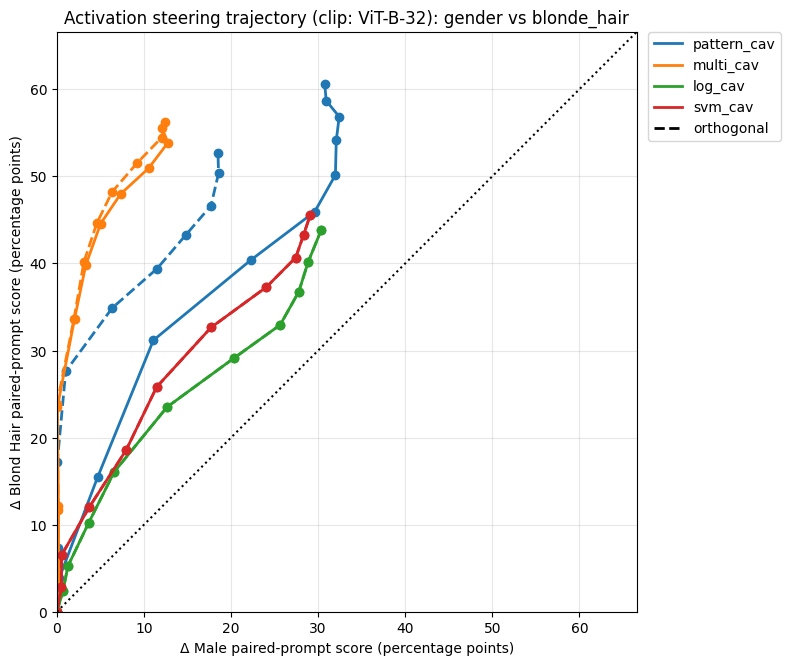

In [12]:
# --- Run ---
_ = run_activation_steering_delta_phase_plot(
    results_root=decodings_dir,
    move_target_concept="Blond_Hair",
    target_concepts=["Blond_Hair"],
    cav_types=["pattern_cav", "multi_cav", "log_cav", "svm_cav"],
    alpha_vals=[0,0,0,0],
    beta_vals=[1.0, 100.0, 1.0, 1.0],
    concept_names=("gender", "blonde_hair"),
    batch_size=EVALUATION_BATCH_SIZE,
    device=EVALUATION_DEVICE,
    backend=ACTIVATION_STEERING_BACKEND,
    clip_config=CLIP_CONFIG,
)

Using device: cuda; classifier backend: clip


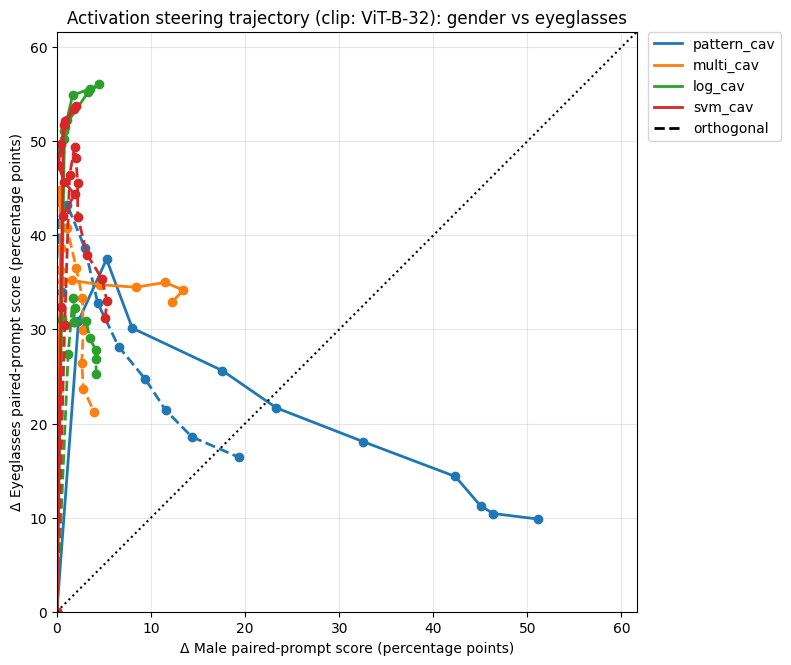

In [13]:
# --- Run ---
_ = run_activation_steering_delta_phase_plot(
    results_root=decodings_dir,
    move_target_concept="Eyeglasses",
    target_concepts=["Eyeglasses"],
    cav_types=["pattern_cav", "multi_cav", "log_cav", "svm_cav"],
    alpha_vals=[0,0,0,0],
    beta_vals=[1.0, 100.0, 1.0, 1.0],
    concept_names=("gender", "eyeglasses"),
    batch_size=EVALUATION_BATCH_SIZE,
    device=EVALUATION_DEVICE,
    backend=ACTIVATION_STEERING_BACKEND,
    clip_config=CLIP_CONFIG,
)

Using device: cuda; classifier backend: clip


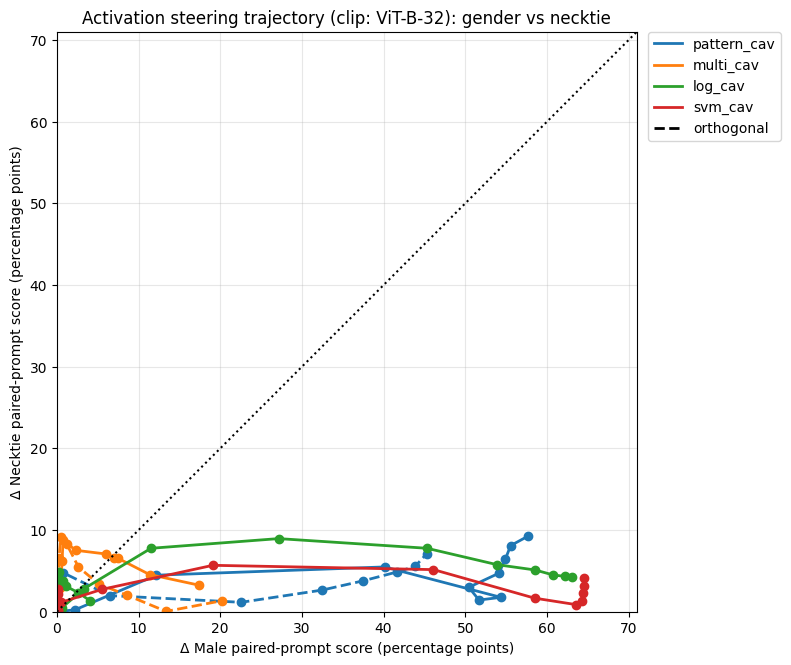

In [14]:
# --- Run ---
_ = run_activation_steering_delta_phase_plot(
    results_root=decodings_dir,
    move_target_concept="Wearing_Necktie",
    target_concepts=["Wearing_Necktie"],
    cav_types=["pattern_cav", "multi_cav", "log_cav", "svm_cav"],
    alpha_vals=[0,0,0,0],
    beta_vals=[1.0, 100.0, 1.0, 1.0],
    concept_names=("gender", "necktie"),
    batch_size=EVALUATION_BATCH_SIZE,
    device=EVALUATION_DEVICE,
    backend=ACTIVATION_STEERING_BACKEND,
    clip_config=CLIP_CONFIG,
)

In [ ]:
# Optional legacy comparison (requires the VGG cells and checkpoint paths above):
# vgg_results = run_activation_steering_delta_phase_plot(
#     results_root=decodings_dir,
#     move_target_concept="Wearing_Necktie",
#     target_concepts=["Wearing_Necktie"],
#     cav_types=["pattern_cav", "multi_cav", "log_cav", "svm_cav"],
#     alpha_vals=[0, 0, 0, 0],
#     beta_vals=[1.0, 100.0, 1.0, 1.0],
#     concept_names=("gender", "necktie"),
#     batch_size=EVALUATION_BATCH_SIZE,
#     device=EVALUATION_DEVICE,
#     backend="vgg",
# )